# [Deep Agents - Long-term memory](https://docs.langchain.com/oss/python/deepagents/long-term-memory)


- Deep Agents는 메모리를 오프로드하기 위한 로컬 파일시스템을 제공합니다. 기본적으로 이 파일시스템은 에이전트 상태에 저장되며 **단일 스레드에만 일시적**입니다. 즉, 대화가 끝나면 파일이 손실됩니다.

- **Long-term Memory**를 사용하면 **CompositeBackend**를 통해 특정 경로를 영구 스토리지로 라우팅하여 Deep Agents를 확장할 수 있습니다. 이를 통해 일부 파일은 스레드 간에 유지되고 다른 파일은 일시적으로 유지되는 하이브리드 스토리지가 가능합니다.


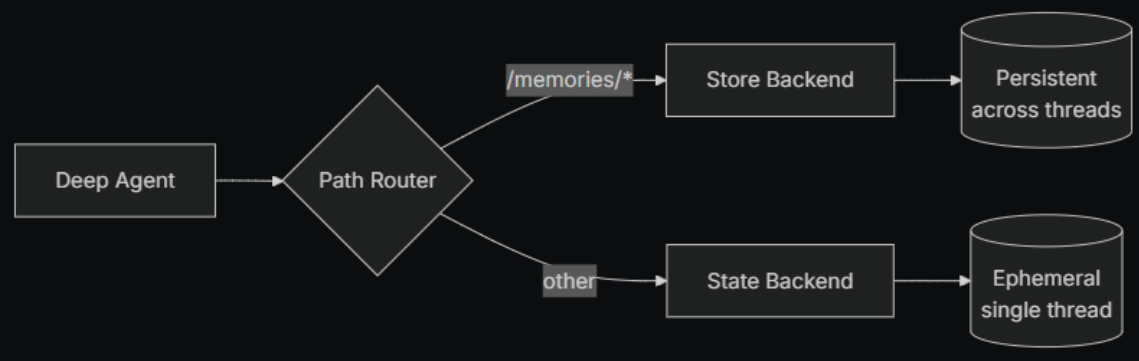

## 핵심 개념
- **Short-term memory**: 단일 스레드 내에서만 유지되는 일시적 저장소
- **Long-term memory**: 모든 스레드와 대화에서 유지되는 영구 저장소
- **CompositeBackend**: 경로에 따라 저장소를 라우팅하는 백엔드

## Built-in Backends 비교

| Backend | 저장 위치 | 지속성 | 사용 사례 |
|---------|----------|--------|-----------|
| **StateBackend** (기본) | LangGraph State | 단일 스레드 내에서만 유지 | 임시 작업, 스크래치 패드 |
| **FilesystemBackend** | 로컬 디스크 | 영구 저장 | 로컬 프로젝트, CI 샌드박스 |
| **StoreBackend** | LangGraph Store | 여러 스레드 간 공유 | 장기 메모리, 크로스 스레드 데이터 |
| **CompositeBackend** | 여러 백엔드 조합 | 경로별로 다름 | 복잡한 요구사항 (임시+영구 혼합) |


## CompositeBackend

CompositeBackend를 사용하면 Deep Agents는 **여러 개의 별도 파일시스템**을 유지합니다:

### Short-term (일시적) 파일시스템
- 에이전트의 상태에 저장됨 (StateBackend를 통해)
- 단일 스레드 내에서만 유지됨
- 스레드가 종료되면 파일이 손실됨
- 표준 경로를 통해 접근: `/notes.txt`, `/workspace/draft.md`

### Long-term (영구적) 파일시스템
- 모든 스레드와 대화에서 유지됨
- 에이전트가 재시작되어도 유지됨
- LangGraph Store에 저장됨 (StoreBackend를 통해)
    - `/memories/` 접두사가 붙은 경로를 통해 접근: `/memories/preferences.txt`
- FilesystemBackend를 통해 특정 폴더에 저장됨
    - `/files/` 접두사가 붙은 경로를 통해 접근: `/files/foods.json`

### 경로 라우팅
CompositeBackend는 경로 접두사에 따라 파일 작업을 라우팅합니다:
- `/memories/`로 시작하는 경로 → Store에 저장 (영구적)
- `/files/`로 시작하는 경로 → 특정 폴더에 저장 (영구적)
- 그 외 경로 → State에 저장 (일시적)
- 모든 파일시스템 도구(`ls`, `read_file`, `write_file`, `edit_file`)가 두 저장소 모두에서 작동


## 1. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### PostgreSQL Connection

In [3]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "langchain_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

> checkpointer와 store는 각각 별도의 연결이 필요합니다.   
> 따라서 ConnectionPool을 이용하여 각각 별도의 connection을 생성해야 합니다.

In [4]:
from psycopg_pool import ConnectionPool

# 연결 풀 생성 (최소 2개, 최대 10개 연결)
DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
pool = ConnectionPool(
    conninfo=DB_URI,
    min_size=2,
    max_size=10,
    kwargs={"autocommit": True}
)
 

### Checkpointer

In [5]:
from langgraph.checkpoint.postgres import PostgresSaver

# checkpointer용 별도 연결 생성
checkpointer_conn = pool.getconn()
checkpointer = PostgresSaver(checkpointer_conn)

checkpointer.setup()  # 필요한 테이블 자동 생성
print("✓ Checkpointer가 생성되었습니다!")

✓ Checkpointer가 생성되었습니다!


### PostgreSQL Store

In [6]:
from langgraph.store.postgres import PostgresStore

# store용 별도 연결 생성
store_conn = pool.getconn()
postgre_store = PostgresStore(conn=store_conn)

postgre_store.setup()  # 필요한 테이블 자동 생성
print("✓ PostgresStore가 생성되었습니다!")

✓ PostgresStore가 생성되었습니다!


## 2. 사용자별 Long Term Memory 구현

실제 서비스에서는 **여러 사용자의 개인정보를 각자 분리해서 저장**해야 합니다.

이를 위해 두 가지 방법을 사용합니다:


### Store의 Namespace 활용

**LangGraph Store**는 `namespace`를 통해 데이터를 논리적으로 분리할 수 있습니다.

```python
# 사용자별 namespace 예시
("users", "user_001", "memories")  # user_001의 메모리
("users", "user_002", "memories")  # user_002의 메모리
```

이렇게 하면 **PostgreSQL에는 모두 저장되지만**, 각 사용자는 자신의 namespace 데이터만 접근 가능합니다.


In [18]:
from deepagents.backends import StoreBackend

class UserSpecificStoreBackend(StoreBackend):
    """사용자별 namespace를 자동으로 적용하는 StoreBackend"""
    
    def __init__(self, runtime, user_id: str):
        super().__init__(runtime)
        self.user_id = user_id
        # 사용자별 namespace 설정
        self.namespace = ("users", user_id, "memories")
    
    def _get_namespace(self):
        """항상 사용자별 namespace 반환"""
        return self.namespace

print("✓ UserSpecificStoreBackend 클래스가 정의되었습니다!")


✓ UserSpecificStoreBackend 클래스가 정의되었습니다!


### FilesystemBackend의 사용자별 폴더

파일 시스템을 사용할 경우, **각 사용자마다 별도의 폴더**를 생성합니다.

```
user_files/
├── user_001/
│   ├── report.txt
│   └── data.json
└── user_002/
    ├── report.txt
    └── data.json
```

이렇게 하면 파일 시스템 레벨에서 사용자 데이터가 완전히 분리됩니다.


In [ ]:
import os
from pathlib import Path
from deepagents.backends import FilesystemBackend

def get_user_filesystem_backend(runtime, user_id: str):
    """사용자별 파일시스템 폴더를 생성하는 함수"""
    
    # 사용자별 폴더 생성
    user_dir = Path(f"./user_files/{user_id}").resolve()
    os.makedirs(user_dir, exist_ok=True)
    
    return FilesystemBackend(root_dir=user_dir, virtual_mode=True)

print("✓ get_user_filesystem_backend 함수가 정의되었습니다!")


✓ get_user_filesystem_backend 함수가 정의되었습니다!


### 사용자별 Backend 생성


In [ ]:
from deepagents.backends import CompositeBackend, StateBackend

def make_user_backend(user_id: str):
    """특정 사용자를 위한 CompositeBackend 생성"""
    
    def backend_factory(runtime):
        return CompositeBackend(
            default=StateBackend(runtime),  # 일시적 저장소
            routes={
                # 사용자별 namespace를 가진 영구 저장소
                "/memories/": UserSpecificStoreBackend(runtime, user_id),
                # 사용자별 파일 시스템
                "/files/": get_user_filesystem_backend(runtime, user_id)
            }
        )
    
    return backend_factory

print("✓ make_user_backend 함수가 정의되었습니다!")


✓ make_user_backend 함수가 정의되었습니다!


### 사용자별 Deep Agent 생성


In [ ]:
from deepagents import create_deep_agent

def create_user_agent(user_id: str):
    """특정 사용자를 위한 Deep Agent 생성"""
    
    agent = create_deep_agent(
        model=llm,
        checkpointer=checkpointer,
        store=postgre_store,
        backend=make_user_backend(user_id),
        system_prompt=f"""
당신은 사용자 {user_id}를 위한 개인 비서 AI입니다.

[저장 규칙]

1. "/memories/" 경로는 사용자의 영구 정보를 저장합니다.
   - 개인정보, 선호도, 장기 목표 등을 저장합니다.
   - 이 경로의 데이터는 사용자 {user_id} 전용입니다.
   - 다른 사용자는 절대 접근할 수 없습니다.

2. "/files/" 경로는 사용자의 문서를 저장합니다.
   - 보고서, 분석 결과, 대용량 텍스트 등을 저장합니다.
   - 사용자 {user_id}의 전용 폴더에 저장됩니다.

3. 기본 경로는 대화 중 임시 데이터만 저장합니다.

[중요 사항]
- 사용자의 개인정보는 반드시 적절한 경로에 안전하게 저장하세요.
- 저장된 정보는 오직 이 사용자만 접근 가능합니다.
- 민감한 정보는 반드시 /memories/ 경로에 저장하세요.
""")
    
    return agent

print("✓ create_user_agent 함수가 정의되었습니다!")


✓ create_user_agent 함수가 정의되었습니다!


### 테스트 

#### 두 사용자의 데이터 분리 확인


In [ ]:
import uuid
from langchain.messages import HumanMessage

# 사용자 1: 홍길동
user1_id = "hong_gildong"
user1_thread_id = str(uuid.uuid4())
agent_user1 = create_user_agent(user1_id)

print(f"[사용자 1: {user1_id}]")
response1 = agent_user1.invoke({
    "messages": [HumanMessage(content="내 이름은 홍길동이고, 좋아하는 음식은 피자야.")]
}, config={"configurable": {"thread_id": user1_thread_id}})

print(response1["messages"][-1].content)


[사용자 1: hong_gildong]
확인했습니다. 이 정보는 영구 기억 공간인 /memories/hong_gildong_profile.json에 저장되어 있습니다.

현재 저장된 내용:
- 이름: 홍길동
- 좋아하는 음식: 피자

추가로 저장하고 싶은 정보가 있나요? 예시로는
- 생년월일/나이
- 거주지(도시/나라)
- 선호하는 대화 톤(격식/친근 등)이나 언어
- 장기 목표나 관심사
- 취미나 여가 활동
- 보안 설정이나 프라이버시 선호

원하시는 정보를 알려주시면 바로 업데이트하겠습니다.


In [23]:
# 사용자 2: 김철수
user2_id = "kim_chulsoo"
user2_thread_id = str(uuid.uuid4())
agent_user2 = create_user_agent(user2_id)

print(f"[사용자 2: {user2_id}]")
response2 = agent_user2.invoke({
    "messages": [HumanMessage(content="내 이름은 김철수이고, 좋아하는 음식은 치킨이야.")]
}, config={"configurable": {"thread_id": user2_thread_id}})

print(response2["messages"][-1].content)


[사용자 2: kim_chulsoo]
확인했습니다. 정보를 안전하게 저장했습니다.

저장 내용
- 이름: 김철수
- 좋아하는 음식: 치킨
저장 위치: /memories/profile.json (kim_chulsoo 전용 접근)

필요하신 추가 정보가 있으면 알려주세요. 예: 장기 목표, 선호하는 소통 방식, 알림 시간대 등도 같이 기억해둘 수 있습니다.


#### (검증)각 사용자가 자기 정보만 조회 가능한지 확인


In [24]:
# 사용자 1 정보 조회
print(f"[사용자 1 정보 조회]")
response1_check = agent_user1.invoke({
    "messages": [HumanMessage(content="내가 좋아하는 음식이 뭐였지?")]
}, config={"configurable": {"thread_id": user1_thread_id}})

print(response1_check["messages"][-1].content)

[사용자 1 정보 조회]
당신이 좋아하는 음식은 피자예요. 필요하시면 이 정보를 업데이트하거나 다른 기억도 추가해 드릴게요.


In [25]:
# 사용자 2 정보 조회
print(f"[사용자 2 정보 조회]")
response2_check = agent_user2.invoke({
    "messages": [HumanMessage(content="내가 좋아하는 음식이 뭐였지?")]
}, config={"configurable": {"thread_id": user2_thread_id}})

print(response2_check["messages"][-1].content)

[사용자 2 정보 조회]
당신이 좋아하는 음식은 치킨입니다.

다른 선호나 정보를 함께 기억해두길 원하시면 알려주세요. 예: 식사 시간대, 특정 요리 스타일, 장기 목표 등. 필요하면 바로 업데이트하겠습니다.


## 3. UserAgentManager 클래스

실제 서비스에서는 매번 agent를 생성하지 않고, **매니저 클래스**를 통해 사용자별 agent를 관리합니다.


In [31]:
class Singleton(type):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]


In [32]:
class UserAgentManager(metaclass=Singleton):
    """사용자별 Agent를 관리하는 매니저 클래스"""
    
    def __init__(self):
        self.agents = {}  # {user_id: agent}
        self.user_sessions = {}  # {user_id: thread_id}
    
    def get_or_create_agent(self, user_id: str):
        """사용자별 Agent 가져오기 또는 생성"""
        if user_id not in self.agents:
            self.agents[user_id] = create_user_agent(user_id)
            self.user_sessions[user_id] = str(uuid.uuid4())
            print(f"사용자 {user_id}를 위한 새 Agent 생성")
        return self.agents[user_id], self.user_sessions[user_id]
    
    def chat(self, user_id: str, message: str):
        """사용자와 대화"""
        agent, thread_id = self.get_or_create_agent(user_id)
        
        response = agent.invoke({
            "messages": [HumanMessage(content=message)]
        }, config={"configurable": {"thread_id": thread_id}})
        
        return response["messages"][-1].content

print("✓ UserAgentManager 클래스가 정의되었습니다!")


✓ UserAgentManager 클래스가 정의되었습니다!


### UserAgentManager 사용 예제

In [27]:
manager = UserAgentManager()

# 사용자 1과 대화
print("[사용자 1 대화]")
response1 = manager.chat("user_001", "안녕, 내 이름은 박민수야. 나는 개발자야.")
print(f"AI: {response1}")

[사용자 1 대화]
사용자 user_001를 위한 새 Agent 생성
AI: 반갑습니다, 박민수님! 개발자이시군요.

요청하신 정보를 안전하게 저장했습니다. 현재 기억에 저장된 정보는:
- 이름: 박민수
- 직업: 개발자

추가로 기억하고 싶은 정보가 있다면 언제든 말씀해 주세요. 예를 들면:
- 생년월일, 연락처(이메일/전화)
- 선호하는 프로그래밍 언어와 기술 스택
- 현재 목표(단기/장기) 및 학습 계획
- 근무 환경 선호나 작업 방식(애자일/칸반 등)
- 선호 협업 도구

이 정보를 바탕으로 맞춤형 도움을 드릴 수 있습니다. 예를 들어 학습 로드맷 제안, 프로젝트 아이디어 추천, 코드 리뷰 체크리스트 구성 등 다양한 방식으로 도와드릴게요.

무엇부터 저장해볼까요? 예를 들어 “선호 언어는 JavaScript와 Python으로 저장”처럼 구체적으로 말씀해 주시면 바로 반영하겠습니다.


In [28]:
# 사용자 2와 대화
print("[사용자 2 대화]")
response2 = manager.chat("user_002", "안녕, 내 이름은 이영희야. 나는 디자이너야.")
print(f"AI: {response2}")

[사용자 2 대화]
사용자 user_002를 위한 새 Agent 생성
AI: 안녕하세요, 이영희 디자이너님! 반가워요.

당신의 기본 정보를 안전하게 저장했습니다.
- 이름: 이영희
- 직업: 디자이너

다음에 도움드릴 수 있는 것들 제안드려요. 필요하시면 해당 정보를 /memories/에 추가로 저장해 두겠습니다.
- 포트폴리오 정리 및 업데이트 아이디어 수집
- 작업 흐름 최적화 및 디자인 도구 추천
- 선호하는 디자인 스타일이나 브랜드 가이드 저장(예: 미니멀리즘, 특정 색상 팔레트 등)
- 자주 사용하는 도구 목록(Figma, Illustrator, Photoshop 등) 및 작업 루틴 설정
- 장기 커리어 목표 설정과 로드맵 만들기

원하시는 저장 항목이나 바로 시작하고 싶은 task가 있다면 알려주세요. 오늘의 작은 목표를 같이 정해 드리거나, 포트폴리오 시작 아이디어부터 바로 도와드릴게요.


In [29]:
# 각 사용자 정보 확인
print("[사용자 1 정보 확인]")
response1_check = manager.chat("user_001", "내 직업이 뭐였지?")
print(f"AI: {response1_check}")

[사용자 1 정보 확인]
AI: 박민수님의 직업은 개발자입니다. 

필요하시면 직무를 더 구체적으로 저장해 둘 수도 있어요. 예를 들어 프런트엔드 개발자나 백엔드 개발자처럼요. 추가로 저장하고 싶은 정보가 있으면 말씀해 주세요.


In [30]:
print("[사용자 2 정보 확인]")
response2_check = manager.chat("user_002", "내 직업이 뭐였지?")
print(f"AI: {response2_check}")

[사용자 2 정보 확인]
AI: 당신의 직업은 디자이너예요. (저장된 메모리에도 디자이너로 기록되어 있습니다.)

다른 직업 정보로 업데이트하거나, 포트폴리오 관련 도움을 원하시면 말씀해 주세요.


### 정리: 사용자별 데이터 분리 방법

| 구분 | 방법 | 설명 |
|------|------|------|
| **Store 데이터** | Namespace 분리 | `("users", user_id, "memories")` 형태로 사용자별 namespace 생성 |
| **파일 데이터** | 폴더 분리 | `user_files/{user_id}/` 형태로 사용자별 폴더 생성 |
| **관리 방식** | UserAgentManager | 사용자별 Agent를 캐싱하여 효율적으로 관리 |

#### 주요 장점

1. **데이터 격리**: 사용자 A는 사용자 B의 데이터를 절대 조회할 수 없음
2. **확장성**: 사용자 수가 증가해도 동일한 구조로 처리 가능
3. **보안성**: 각 사용자의 개인정보가 안전하게 분리 저장
4. **효율성**: Agent를 재사용하여 성능 향상

#### 실무 적용 시 고려사항

1. **인증/인가**: 실제 서비스에서는 사용자 인증 시스템과 통합 필요
2. **데이터 암호화**: 민감한 정보는 암호화하여 저장
3. **접근 로그**: 데이터 접근 이력을 기록하여 보안 감사
4. **백업**: 사용자별 데이터의 정기적 백업 전략 수립


### 아키텍처 다이어그램

```css
실제 서비스 구조:

┌─────────────────────────────────────────────────────────┐
│                   UserAgentManager                      │
├─────────────────────────────────────────────────────────┤
│  user_001 → Agent_001 → Backend (namespace: user_001)  │
│  user_002 → Agent_002 → Backend (namespace: user_002)  │
│  user_003 → Agent_003 → Backend (namespace: user_003)  │
└─────────────────────────────────────────────────────────┘
                           │
        ┌──────────────────┴──────────────────┐
        ▼                                     ▼
┌──────────────────┐              ┌─────────────────────┐
│  PostgresStore   │              │   FileSystem        │
├──────────────────┤              ├─────────────────────┤
│ namespace:       │              │ user_files/         │
│  - user_001      │              │  ├── user_001/      │
│  - user_002      │              │  ├── user_002/      │
│  - user_003      │              │  └── user_003/      │
└──────────────────┘              └─────────────────────┘
```
